In [17]:
import ctypes, os, subprocess, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.linalg import eigh
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print('imports OK')

imports OK


In [18]:
SERIAL_DIR   = 'serial'
PARALLEL_DIR = 'parallel'

def compile_lib(directory, target):
    result = subprocess.run(['make', '-C', directory, '-B'],
                            capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f'Compilation failed in {directory}')
    path = os.path.join(directory, target)
    assert os.path.exists(path)
    return os.path.abspath(path)

serial_so   = compile_lib(SERIAL_DIR,   'lda_serial.so')
parallel_so = compile_lib(PARALLEL_DIR, 'lda_openmp.so')

print("Compiled OK")

Compiled OK


In [19]:
c_double_p = ctypes.POINTER(ctypes.c_double)
c_int_p    = ctypes.POINTER(ctypes.c_int)

def _bind(lib, name, argtypes, restype=None):
    fn = getattr(lib, name)
    fn.argtypes = argtypes
    fn.restype  = restype if restype else None
    return fn

_serial = ctypes.CDLL(serial_so)
_par    = ctypes.CDLL(parallel_so)

# SERIAL
_serial_means = _bind(_serial, 'compute_class_means',
    [c_double_p, c_int_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p])

_serial_sw = _bind(_serial, 'compute_sw',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int, c_double_p],
     ctypes.c_double)

_serial_sb = _bind(_serial, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, c_double_p])

_serial_proj = _bind(_serial, 'lda_project',
    [c_double_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p])

# PARALLEL
_par_means = _bind(_par, 'compute_class_means',
    [c_double_p, c_int_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p])

_par_sw = _bind(_par, 'compute_sw_parallel',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, ctypes.c_int],
     ctypes.c_double)

_par_sb = _bind(_par, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, c_double_p])

_par_proj = _bind(_par, 'lda_project',
    [c_double_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p])

print("Bindings OK")

Bindings OK


In [27]:
DATA_DIR = 'data'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# Assume last column is the label
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values

# Ensure labels are 0..C-1 (VERY IMPORTANT for C code)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

print("Processed shapes:", X_train.shape, X_test.shape)

Train shape: (7352, 563)
Test shape : (2947, 563)
Processed shapes: (7352, 562) (2947, 562)


In [28]:
!ls data

test.csv  train.csv


In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

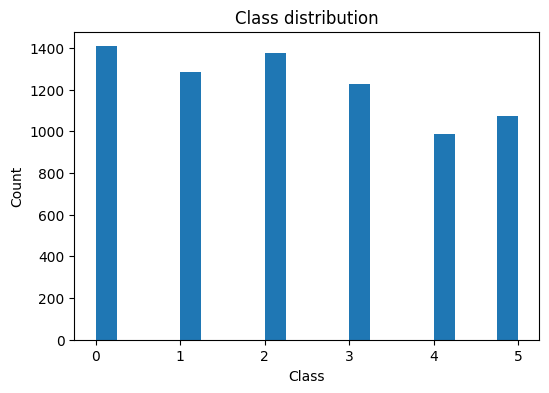

In [32]:
plt.figure(figsize=(6,4))
plt.hist(y_train, bins=20)
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [33]:
def dptr(a): return a.ctypes.data_as(c_double_p)
def iptr(a): return a.ctypes.data_as(c_int_p)

n, d = X_train.shape
C = len(np.unique(y_train))
K = C - 1

print("n, d, C:", n, d, C)

n, d, C: 7352 562 6


In [34]:
def run_serial_lda(X, y, n, d, C):
    means       = np.zeros((C, d))
    counts      = np.zeros(C, dtype=np.int32)
    global_mean = np.zeros(d)
    SW          = np.zeros((d, d))
    SB          = np.zeros((d, d))

    _serial_means(dptr(X), iptr(y), n, d, C,
                  dptr(means), iptr(counts), dptr(global_mean))

    t_sw = _serial_sw(dptr(X), iptr(y), dptr(means),
                      n, d, C, dptr(SW))

    _serial_sb(dptr(means), dptr(global_mean), iptr(counts),
               d, C, dptr(SB))

    eigvals, eigvecs = eigh(SB, SW + 1e-6 * np.eye(d))
    W = eigvecs[:, -K:][:, ::-1].copy(order='C')

    return W, SW, SB, t_sw, means

In [35]:
def run_parallel_lda(X, y, n, d, C, num_threads):
    means       = np.zeros((C, d))
    counts      = np.zeros(C, dtype=np.int32)
    global_mean = np.zeros(d)
    SW          = np.zeros((d, d))
    SB          = np.zeros((d, d))

    _par_means(dptr(X), iptr(y), n, d, C,
               dptr(means), iptr(counts), dptr(global_mean))

    t_sw = _par_sw(dptr(X), iptr(y), dptr(means),
                   n, d, C, dptr(SW), num_threads)

    _par_sb(dptr(means), dptr(global_mean), iptr(counts),
            d, C, dptr(SB))

    eigvals, eigvecs = eigh(SB, SW + 1e-6 * np.eye(d))
    W = eigvecs[:, -K:][:, ::-1].copy(order='C')

    return W, SW, SB, t_sw

In [36]:
W_ser, SW_ser, SB_ser, t_ser, means = run_serial_lda(X_train, y_train, n, d, C)
W_par, SW_par, SB_par, t_par = run_parallel_lda(X_train, y_train, n, d, C, 4)

rel_diff = np.linalg.norm(SW_ser - SW_par) / np.linalg.norm(SW_ser)
print("Relative diff:", rel_diff)

assert rel_diff < 1e-10

Relative diff: 2.4531931208533544e-15


In [37]:
THREADS = [1, 2, 4, 8]
N_REPEATS = 5

means_tmp = np.zeros((C, d))
counts_tmp = np.zeros(C, dtype=np.int32)
gm_tmp = np.zeros(d)

_serial_means(dptr(X_train), iptr(y_train), n, d, C,
              dptr(means_tmp), iptr(counts_tmp), dptr(gm_tmp))

serial_times = []
for _ in range(N_REPEATS):
    SW_tmp = np.zeros((d, d))
    t = _serial_sw(dptr(X_train), iptr(y_train), dptr(means_tmp),
                   n, d, C, dptr(SW_tmp))
    serial_times.append(t)

serial_time = np.mean(serial_times)

par_times = []
for th in THREADS:
    times = []
    for _ in range(N_REPEATS):
        SW_tmp = np.zeros((d, d))
        t = _par_sw(dptr(X_train), iptr(y_train), dptr(means_tmp),
                    n, d, C, dptr(SW_tmp), th)
        times.append(t)
    par_times.append(np.mean(times))

speedups = [serial_time / t for t in par_times]

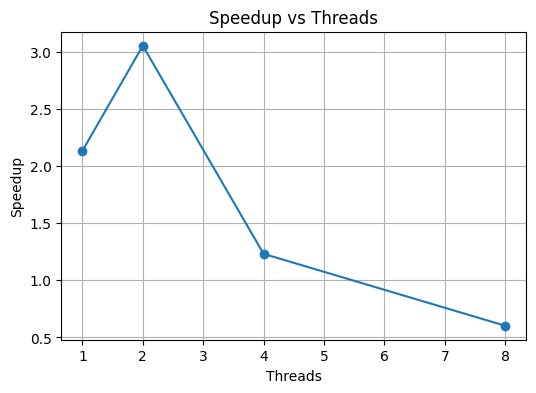

In [38]:
plt.figure(figsize=(6,4))
plt.plot(THREADS, speedups, marker='o')
plt.title("Speedup vs Threads")
plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.grid()
plt.show()

In [39]:
def project(X, W):
    return X @ W

Y_train = project(X_train, W_ser)
Y_test  = project(X_test,  W_ser)

In [40]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(Y_train, y_train)

y_pred = knn.predict(Y_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.46012894468951476
              precision    recall  f1-score   support

           0       0.80      0.72      0.76       537
           1       0.37      0.39      0.38       491
           2       0.49      0.48      0.49       532
           3       0.37      0.37      0.37       496
           4       0.41      0.39      0.40       420
           5       0.33      0.38      0.35       471

    accuracy                           0.46      2947
   macro avg       0.46      0.45      0.46      2947
weighted avg       0.47      0.46      0.46      2947



In [41]:
W_par_c = np.ascontiguousarray(W_par)

Y_train_par = np.zeros((n, K))
_par_proj(dptr(X_train), dptr(W_par_c), n, d, K, dptr(Y_train_par))

Y_test_par = np.zeros((X_test.shape[0], K))
_par_proj(dptr(X_test), dptr(W_par_c), X_test.shape[0], d, K, dptr(Y_test_par))

knn2 = KNeighborsClassifier(n_neighbors=1)
knn2.fit(Y_train_par, y_train)

y_pred_par = knn2.predict(Y_test_par)

print("Parallel Accuracy:", accuracy_score(y_test, y_pred_par))

Parallel Accuracy: 0.15948422124194095


In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_sk = lda.predict(X_test)

print("Sklearn Accuracy:", accuracy_score(y_test, y_pred_sk))

Sklearn Accuracy: 0.9643705463182898
